# LLM Hallucination-- EDA + 95% Accuracy + Hallucination Detection ML Classification

## Analysing Hallucination Patterns Across 5 Major LLMs -- GPT-4o, Claude, Gemini, Mistral, Llama (200 Records)

### Overview¶

Large Language Model (LLM) hallucinations are one of the most critical reliability challenges in AI deployment. This notebook delivers a comprehensive Exploratory Data Analysis and Machine Learning pipeline on a curated hallucination annotation dataset covering 200 LLM responses across 5 frontier models, 8 domains, and 5 prompt types.

### Objectives

1.Understand data quality -- structure, null handling, and feature profiles

2.Target analysis -- hallucination rate, severity, and type breakdown

3.Model comparison -- which LLMs hallucinate most ?

4.Domain & task analysis -- where do hallucinations cluster ?

5.Prompt type analysis -- which prompts trigger more hallucinations ?

6.Mitigation strategies -- does RAG or CoT reduce hallucination ?

7.Annotator agreement & confidence analysis

8.ML Classification -- predict hallucination_label using 7 models



### Dataset Columns

| Column | Description |
|---|---|
| `model_name` | LLM tested (GPT-4o, Claude-3.5-Sonnet, Gemini-1.5-Pro, etc.) |
| `prompt_type` | Direct-Factual / Adversarial / Ambiguous / Long-Context / Multi-Hop |
| `domain` | Subject domain -- Medicine, Finance, Law, Science, etc. |
| `task_type` | QA / Summarization / Fact-Verification / Open-Generation / etc. |
| `language` | English / Spanish / Mandarin / Arabic / French / Hindi / German |
| `hallucination_label` | **Target -- 1 = Hallucinated, 0 = Not Hallucinated** |
| `hallucination_type` | Type of error (Factual-Contradiction, Overclaim, etc.) |
| `severity` | High / Medium / Low (only for hallucinated records) |
| `domain_risk` | High-Stakes / Medium-Stakes / Low-Stakes |
| `annotator_type` | human_expert / human_crowd / llm_judge_gpt4o / llm_judge_claude |
| `annotation_confidence` | Confidence score (0.73–0.99) |
| `mitigation_strategy` | RAG / CoT-Prompting / Self-Consistency / Structured-Prompt |
| `mitigation_applied` | Whether a mitigation was used |
| `intrinsic_or_extrinsic` | Intrinsic (self-generated error) or Extrinsic (conflicts source) |

### 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score,
    ConfusionMatrixDisplay, roc_curve
)
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

MODEL_COLORS = {
    'GPT-4o'            : '#10a37f',
    'Claude-3.5-Sonnet' : '#d97706',
    'Gemini-1.5-Pro'    : '#4285f4',
    'Mistral-Large'     : '#7c3aed',
    'Llama-3.1-70B'     : '#dc2626'
}
SEVERITY_COLORS = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
RISK_COLORS     = {'High-Stakes': '#e74c3c', 'Medium-Stakes': '#f39c12', 'Low-Stakes': '#27ae60'}
C_HALL  = '#e74c3c'
C_CLEAN = '#27ae60'
C1, C2, C3 = '#2980b9', '#e74c3c', '#f39c12'
PAL = [C1, C2, C3, '#27ae60', '#8e44ad', '#16a085', '#d35400', '#2c3e50']

print('All libraries imported successfully.')


All libraries imported successfully.


### 2. Load & Inspect the Dataset

In [4]:
df = pd.read_csv('/content/llm_hallucination_dataset_v1.csv')

df['created_date']  = pd.to_datetime(df['created_date'], errors='coerce')
df['prompt_len']    = df['prompt_text'].str.len()
df['response_len']  = df['response_text'].str.len()
df['prompt_words']  = df['prompt_text'].str.split().str.len()
df['response_words']= df['response_text'].str.split().str.len()

print(f'Shape               : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range          : {df["created_date"].min().date()} -- {df["created_date"].max().date()}')
print(f'LLM models          : {df["model_name"].nunique()}')
print(f'Domains             : {df["domain"].nunique()}')
print(f'Hallucination rate  : {df["hallucination_label"].mean()*100:.1f}%')
df.head(8)

Shape               : 200 rows x 29 columns
Date range          : 2024-09-02 -- 2025-04-29
LLM models          : 5
Domains             : 8
Hallucination rate  : 34.5%


,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes,prompt_len,response_len,prompt_words,response_words
0,70b69889-3b46-4b1e-8f83-b95720bddbcd,2024-11-02,GPT-4o,gpt-4o-2024-11-20,PROMPT_00001,Who invented the telephone?,Multi-Hop,The telephone was invented by Nikola Tesla in ...,History,Question-Answering,...,0.73,RAG,True,PubMed,Extrinsic,NaN,27,126,4,19
1,e93f6574-d3a1-4459-9ccc-8615bc2b627f,2024-09-24,Mistral-Large,mistral-large-2411,PROMPT_00002,What is the boiling point of water at sea level?,Multi-Hop,Water boils at 100 degrees Celsius (212 degree...,Science,Question-Answering,...,0.88,NaN,False,ArXiv,NaN,NaN,48,109,10,16
2,fc732394-9369-4811-8484-e07f69cb6fab,2025-01-29,Mistral-Large,mistral-large-2411,PROMPT_00003,What is the recommended first-line treatment f...,Ambiguous,The first-line pharmacological treatment for T...,Medicine,Question-Answering,...,0.83,Self-Consistency,True,SEC-Filing,Extrinsic,NaN,65,120,10,17
3,2e488a3d-bfc4-4d1e-b59b-eeca571c9c27,2024-10-26,Llama-3.1-70B,llama-3.1-70b-instruct,PROMPT_00004,When was Apple Inc. founded?,Ambiguous,"Apple Inc. was founded on April 1, 1976, by St...",Finance,Question-Answering,...,0.86,CoT-Prompting,True,PubMed,NaN,NaN,28,88,5,16
4,eb1c2d1e-9fb6-46f0-9f65-0f36494db9dc,2024-11-07,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00005,Is it legal to record a phone call without con...,Direct-Factual,"In California, you can legally record a phone ...",Law,Fact-Verification,...,0.95,Structured-Prompt,True,Snopes,Extrinsic,NaN,65,131,12,23
5,fd4104c5-57f2-4b0e-8c71-1f71f9098231,2025-04-15,GPT-4o,gpt-4o-2024-11-20,PROMPT_00006,What does the acronym 'GPU' stand for?,Ambiguous,GPU stands for Graphics Processing Unit.,Technology,Question-Answering,...,0.90,Structured-Prompt,True,Wikipedia,NaN,NaN,38,40,7,6
6,e7eede74-5728-4209-bdc8-44fc1261058f,2025-04-07,Claude-3.5-Sonnet,claude-3-5-sonnet-20241022,PROMPT_00007,Summarize the mechanism of action of Aspirin.,Multi-Hop,Aspirin works by irreversibly inhibiting the e...,Medicine,Summarization,...,0.95,NaN,False,Reuters,NaN,NaN,45,202,7,25
7,f00a071d-1557-4d21-bfe3-fdfea35530c2,2024-10-12,Llama-3.1-70B,llama-3.1-70b-instruct,PROMPT_00008,Tell me about the environmental impact of the ...,Ambiguous,The construction of the Eiffel Tower led to th...,History,Open-Generation,...,0.89,RAG,True,PubMed,Extrinsic,NaN,79,166,13,29


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   record_id               200 non-null    object        
 1   created_date            200 non-null    datetime64[ns]
 2   model_name              200 non-null    object        
 3   model_version           200 non-null    object        
 4   prompt_id               200 non-null    object        
 5   prompt_text             200 non-null    object        
 6   prompt_type             200 non-null    object        
 7   response_text           200 non-null    object        
 8   domain                  200 non-null    object        
 9   task_type               200 non-null    object        
 10  language                200 non-null    object        
 11  hallucination_label     200 non-null    int64         
 12  hallucination_type      69 non-null     object    

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
record_id,200,200,70b69889-3b46-4b1e-8f83-b95720bddbcd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_date,200,NaN,NaN,NaN,2024-12-26 01:19:12,2024-09-02 00:00:00,2024-10-29 18:00:00,2024-12-21 12:00:00,2025-02-21 06:00:00,2025-04-29 00:00:00,NaN
model_name,200,5,Llama-3.1-70B,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_version,200,5,llama-3.1-70b-instruct,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prompt_id,200,200,PROMPT_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prompt_text,200,53,Who invented the telephone?,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prompt_type,200,5,Ambiguous,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_text,200,53,The telephone was invented by Nikola Tesla in ...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
domain,200,8,Medicine,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_type,200,6,Question-Answering,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Data Quality Check

=== Missing Values ===
                        Count    Pct
hallucination_type        131   65.5
hallucination_span        131   65.5
correct_information       131   65.5
correction_text           131   65.5
severity                  131   65.5
mitigation_strategy        39   19.5
intrinsic_or_extrinsic    131   65.5
notes                     200  100.0

Note: hallucination_type, severity, intrinsic_or_extrinsic, hallucination_span,
correct_information, and correction_text are null for non-hallucinated records (expected).
The "notes" column is 100% null and will be dropped from analysis.

=== Duplicate Rows ===
0 duplicate rows


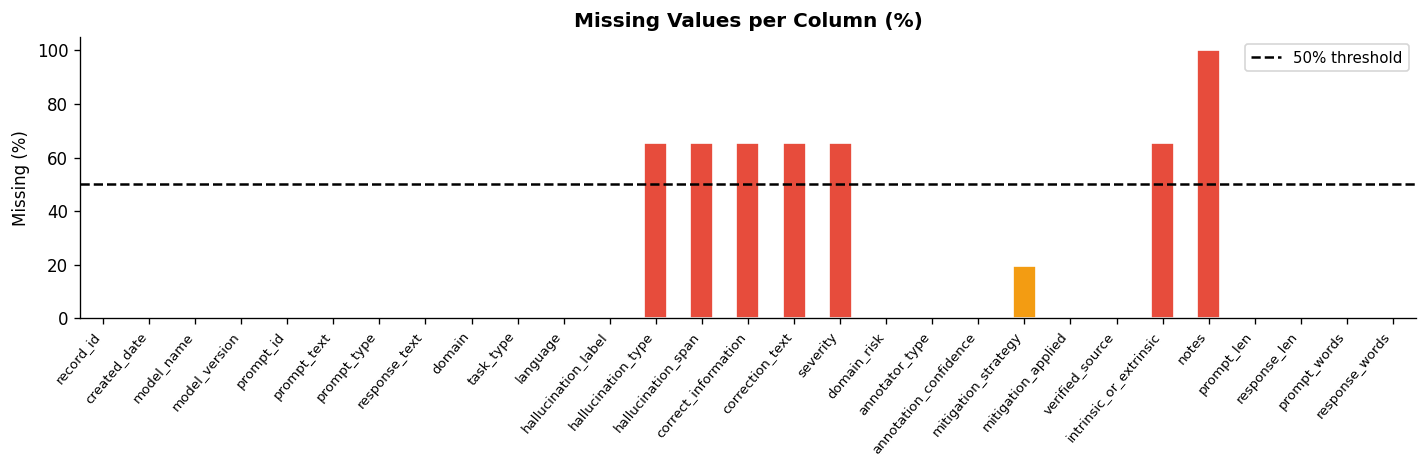

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

print('=== Missing Values ===')
print(pd.DataFrame({'Count': missing, 'Pct': missing_pct})
      .query('Count > 0').to_string())

print('\nNote: hallucination_type, severity, intrinsic_or_extrinsic, hallucination_span,')
print('correct_information, and correction_text are null for non-hallucinated records (expected).')
print('The "notes" column is 100% null and will be dropped from analysis.')

print(f'\n=== Duplicate Rows ===')
print(f'{df.duplicated().sum()} duplicate rows')

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 0 else '#27ae60' for v in missing_pct.values]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(50, color='black', linestyle='--', lw=1.5, label='50% threshold')
ax.set_title('Missing Values per Column (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=50, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 4. Target Variable -- Hallucination Label

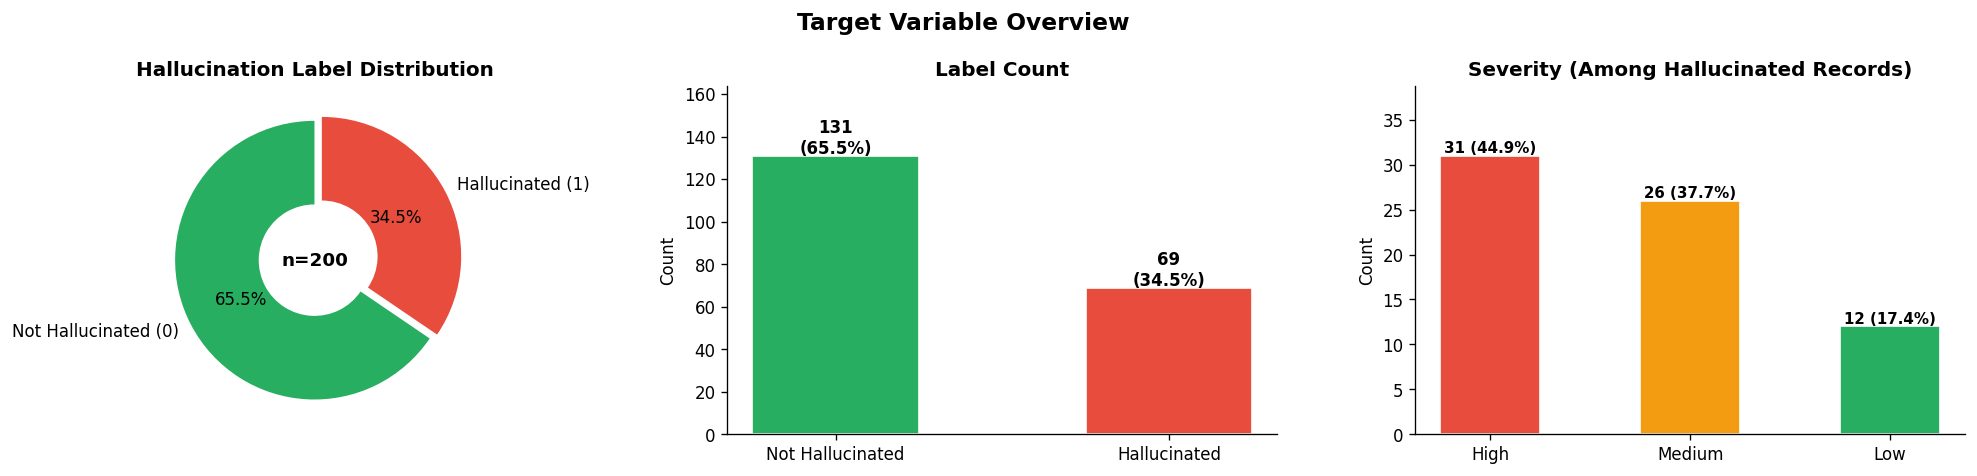

Overall hallucination rate : 34.5%
Clean responses            : 131
Hallucinated responses     : 69


In [8]:
label_counts = df['hallucination_label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].pie(
    label_counts.values,
    labels=['Not Hallucinated (0)', 'Hallucinated (1)'],
    autopct='%1.1f%%',
    colors=[C_CLEAN, C_HALL],
    startangle=90,
    explode=(0, 0.06),
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Hallucination Label Distribution', fontsize=12, fontweight='bold')
axes[0].text(0, 0, f'n={len(df)}', ha='center', va='center', fontsize=11, fontweight='bold')

bars = axes[1].bar(
    ['Not Hallucinated', 'Hallucinated'],
    label_counts.values,
    color=[C_CLEAN, C_HALL], edgecolor='white', width=0.5
)
for bar, val in zip(bars, label_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        f'{val}\n({val/len(df)*100:.1f}%)',
        ha='center', fontweight='bold', fontsize=10
    )
axes[1].set_title('Label Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, label_counts.max() * 1.25)

sev_counts = df[df['hallucination_label'] == 1]['severity'].value_counts()
sev_order  = ['High', 'Medium', 'Low']
sev_counts = sev_counts.reindex(sev_order)
sev_colors = [SEVERITY_COLORS[s] for s in sev_order]
bars2 = axes[2].bar(sev_order, sev_counts.values, color=sev_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, sev_counts.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f'{val} ({val/sev_counts.sum()*100:.1f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )
axes[2].set_title('Severity (Among Hallucinated Records)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_ylim(0, sev_counts.max() * 1.25)

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall hallucination rate : {df["hallucination_label"].mean()*100:.1f}%')
print(f'Clean responses            : {label_counts[0]}')
print(f'Hallucinated responses     : {label_counts[1]}')


### 5. Model-Level Analysis

#### 5.1 Hallucination Rate by LLM

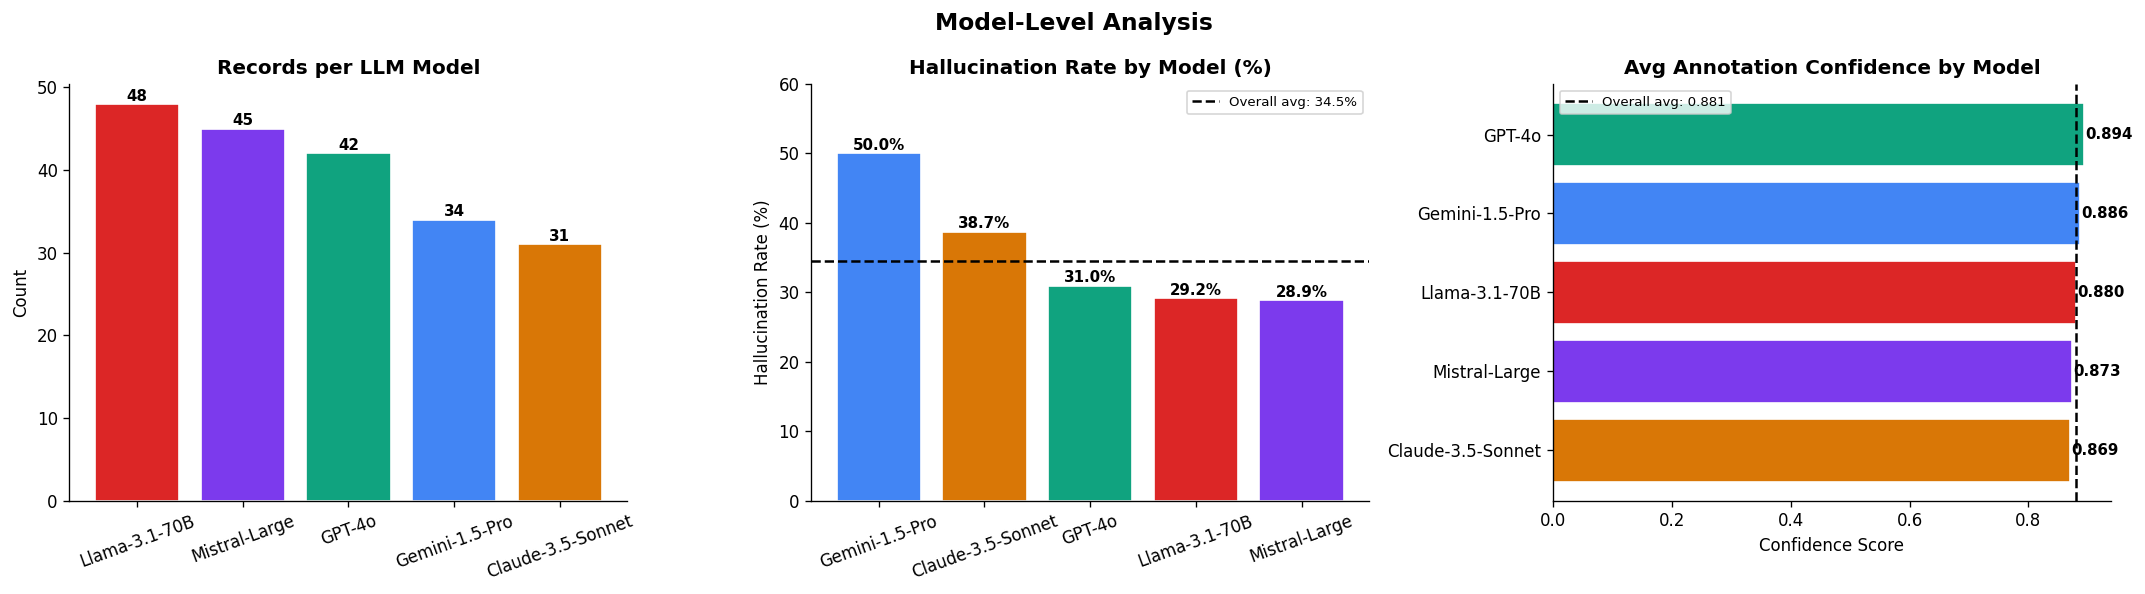

In [9]:
model_counts = df['model_name'].value_counts()
model_hall   = df.groupby('model_name')['hallucination_label'].mean() * 100
model_hall   = model_hall.sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mc_colors = [MODEL_COLORS.get(m, '#adb5bd') for m in model_counts.index]
bars = axes[0].bar(model_counts.index, model_counts.values, color=mc_colors, edgecolor='white')
for bar, val in zip(bars, model_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Records per LLM Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

mh_colors = [MODEL_COLORS.get(m, '#adb5bd') for m in model_hall.index]
bars2 = axes[1].bar(model_hall.index, model_hall.values, color=mh_colors, edgecolor='white')
axes[1].axhline(df['hallucination_label'].mean() * 100, color='black',
                linestyle='--', lw=1.5,
                label=f'Overall avg: {df["hallucination_label"].mean()*100:.1f}%')
for bar, val in zip(bars2, model_hall.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Hallucination Rate by Model (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Hallucination Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)

model_conf = df.groupby('model_name')['annotation_confidence'].mean().sort_values()
conf_colors = [MODEL_COLORS.get(m, '#adb5bd') for m in model_conf.index]
axes[2].barh(model_conf.index, model_conf.values, color=conf_colors, edgecolor='white')
axes[2].axvline(df['annotation_confidence'].mean(), color='black', linestyle='--', lw=1.5,
                label=f'Overall avg: {df["annotation_confidence"].mean():.3f}')
for i, val in enumerate(model_conf.values):
    axes[2].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[2].set_title('Avg Annotation Confidence by Model', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Confidence Score')
axes[2].legend(fontsize=8)

plt.suptitle('Model-Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Hallucination Type & Severity by Model

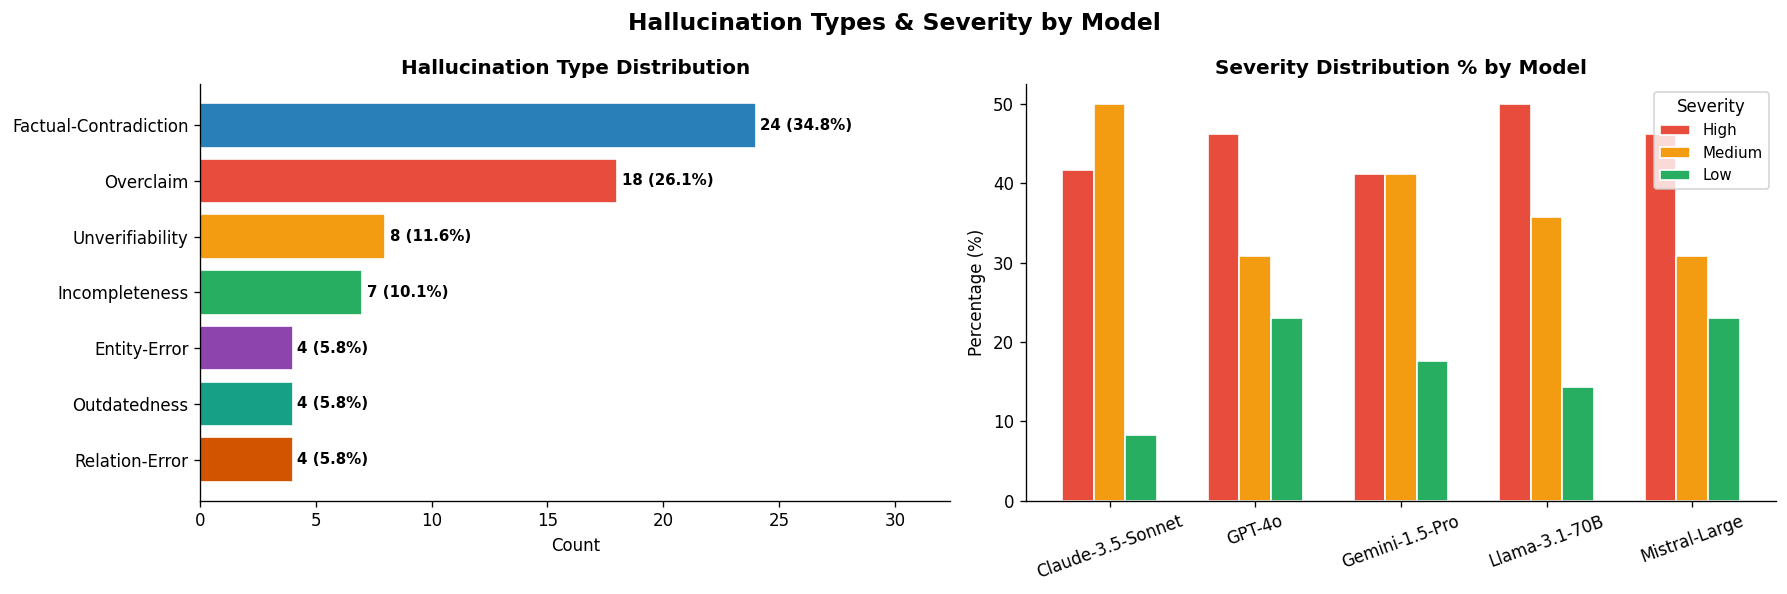

In [10]:
hall_df = df[df['hallucination_label'] == 1].copy()

type_counts = hall_df['hallucination_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tc_colors = PAL[:len(type_counts)]
bars = axes[0].barh(
    type_counts.index[::-1], type_counts.values[::-1],
    color=tc_colors[::-1], edgecolor='white'
)
for bar, val in zip(bars, type_counts.values[::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val} ({val/len(hall_df)*100:.1f}%)', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Hallucination Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_xlim(0, type_counts.max() * 1.35)

model_sev = (
    hall_df.groupby(['model_name', 'severity'])
    .size().unstack(fill_value=0)
)[['High', 'Medium', 'Low']]
model_sev_pct = model_sev.div(model_sev.sum(axis=1), axis=0) * 100

model_sev_pct.plot(
    kind='bar', ax=axes[1],
    color=[SEVERITY_COLORS[s] for s in ['High', 'Medium', 'Low']],
    edgecolor='white', width=0.65
)
axes[1].set_title('Severity Distribution % by Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Severity', fontsize=9)

plt.suptitle('Hallucination Types & Severity by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Domain & Task Analysis

#### 6.1 Hallucination Rate by Domain

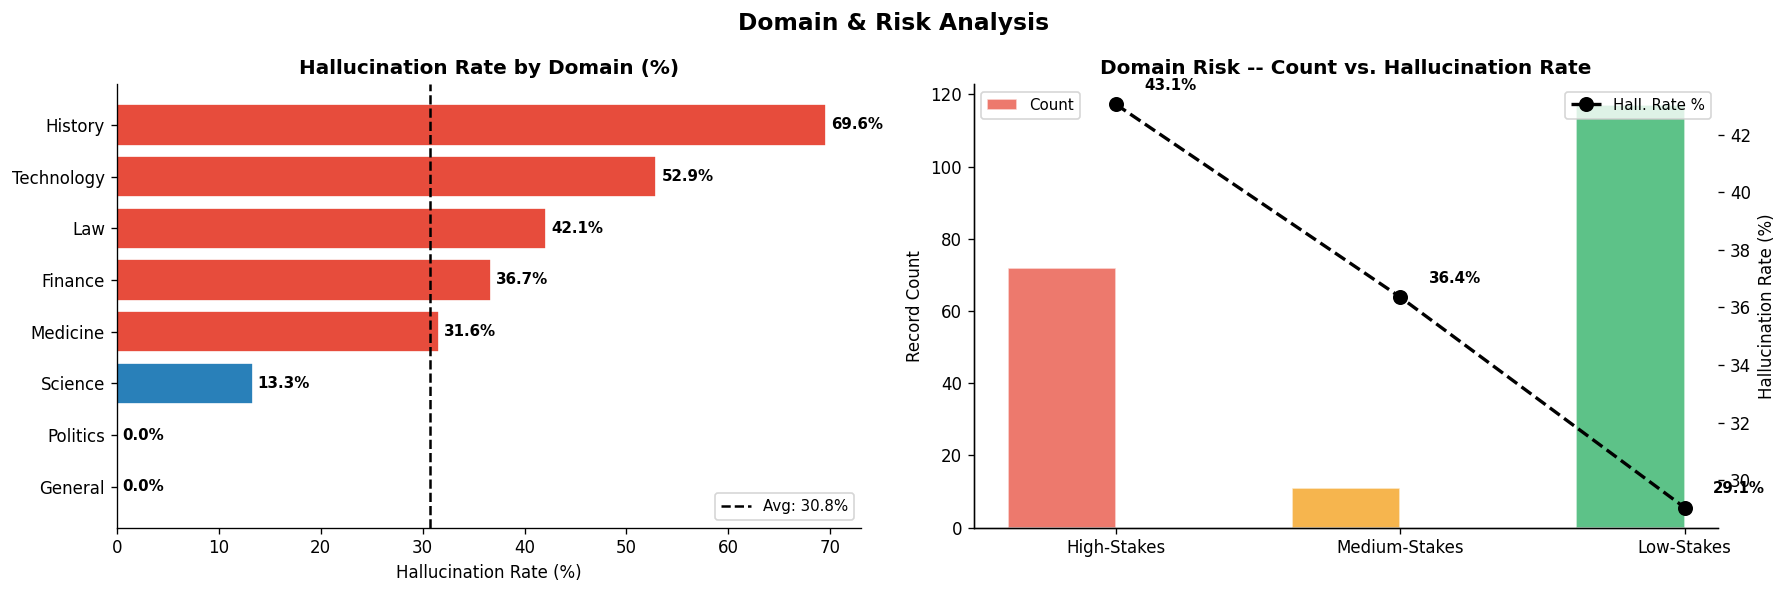

In [11]:
domain_counts = df['domain'].value_counts()
domain_hall   = df.groupby('domain')['hallucination_label'].mean() * 100
domain_hall   = domain_hall.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dc_colors = [C2 if v >= domain_hall.mean() else C1 for v in domain_hall.values]
bars = axes[0].barh(domain_hall.index, domain_hall.values, color=dc_colors, edgecolor='white')
axes[0].axvline(domain_hall.mean(), color='black', linestyle='--', lw=1.5,
                label=f'Avg: {domain_hall.mean():.1f}%')
for bar, val in zip(bars, domain_hall.values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Hallucination Rate by Domain (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hallucination Rate (%)')
axes[0].legend(fontsize=9)

risk_counts = df['domain_risk'].value_counts()
risk_order  = ['High-Stakes', 'Medium-Stakes', 'Low-Stakes']
risk_counts = risk_counts.reindex(risk_order)
risk_col    = [RISK_COLORS[r] for r in risk_order]

risk_hall = df.groupby('domain_risk')['hallucination_label'].mean() * 100
risk_hall  = risk_hall.reindex(risk_order)

x_pos = np.arange(len(risk_order))
width = 0.38
axes[1].bar(x_pos - width/2, risk_counts.values, width, label='Count',
            color=risk_col, edgecolor='white', alpha=0.75)
ax2 = axes[1].twinx()
ax2.plot(x_pos, risk_hall.values, 'ko--', lw=2, markersize=8, label='Hall. Rate %')
ax2.spines['top'].set_visible(False)
for i, val in enumerate(risk_hall.values):
    ax2.text(i + 0.1, val + 0.5, f'{val:.1f}%', fontsize=9, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(risk_order)
axes[1].set_title('Domain Risk -- Count vs. Hallucination Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Record Count')
ax2.set_ylabel('Hallucination Rate (%)')
axes[1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Domain & Risk Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 6.2 Task Type & Prompt Type Analysis

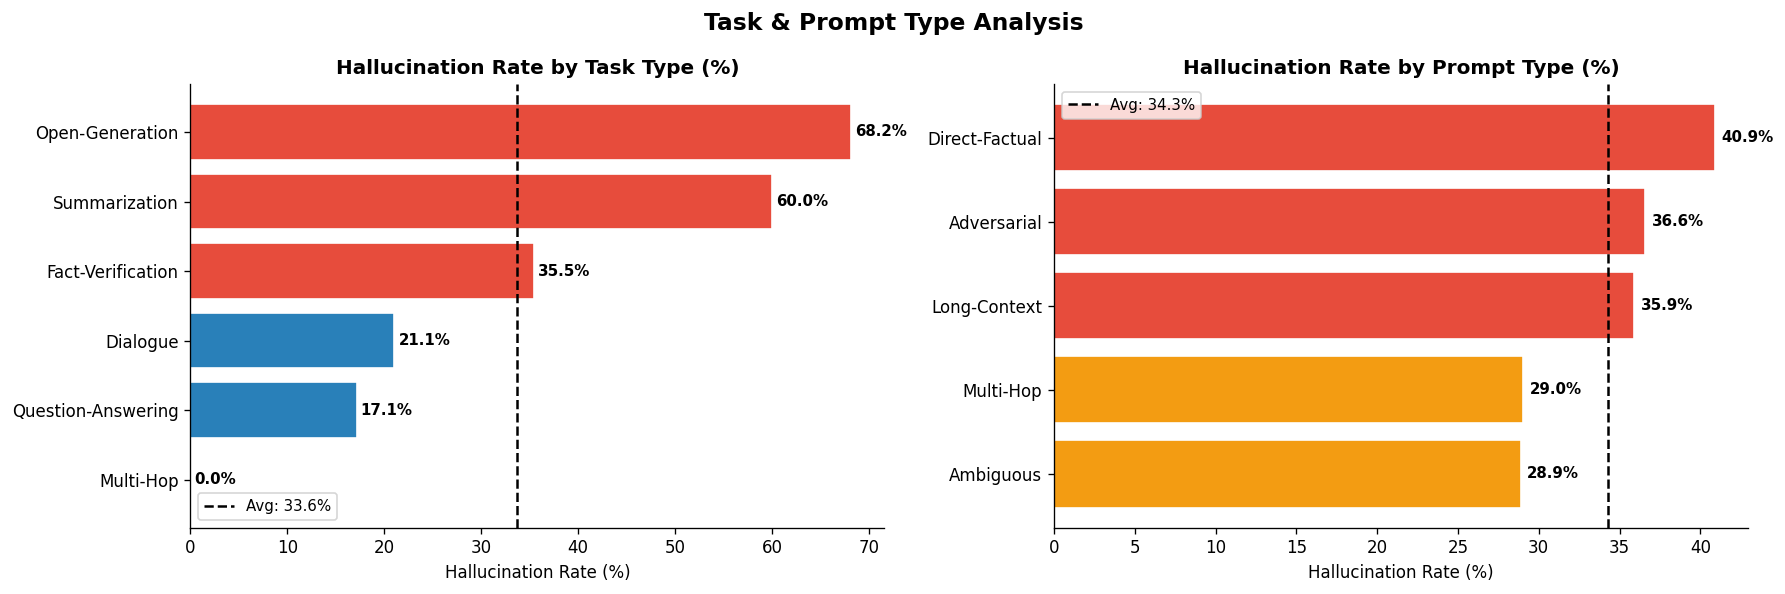

In [12]:
task_hall   = df.groupby('task_type')['hallucination_label'].mean() * 100
prompt_hall = df.groupby('prompt_type')['hallucination_label'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

task_sorted = task_hall.sort_values(ascending=True)
tc2 = [C2 if v >= task_sorted.mean() else C1 for v in task_sorted.values]
bars = axes[0].barh(task_sorted.index, task_sorted.values, color=tc2, edgecolor='white')
axes[0].axvline(task_sorted.mean(), color='black', linestyle='--', lw=1.5,
                label=f'Avg: {task_sorted.mean():.1f}%')
for bar, val in zip(bars, task_sorted.values):
    axes[0].text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Hallucination Rate by Task Type (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hallucination Rate (%)')
axes[0].legend(fontsize=9)

prompt_sorted = prompt_hall.sort_values(ascending=True)
pc2 = [C2 if v >= prompt_sorted.mean() else C3 for v in prompt_sorted.values]
bars2 = axes[1].barh(prompt_sorted.index, prompt_sorted.values, color=pc2, edgecolor='white')
axes[1].axvline(prompt_sorted.mean(), color='black', linestyle='--', lw=1.5,
                label=f'Avg: {prompt_sorted.mean():.1f}%')
for bar, val in zip(bars2, prompt_sorted.values):
    axes[1].text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Hallucination Rate by Prompt Type (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hallucination Rate (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Task & Prompt Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Mitigation Strategy Analysis

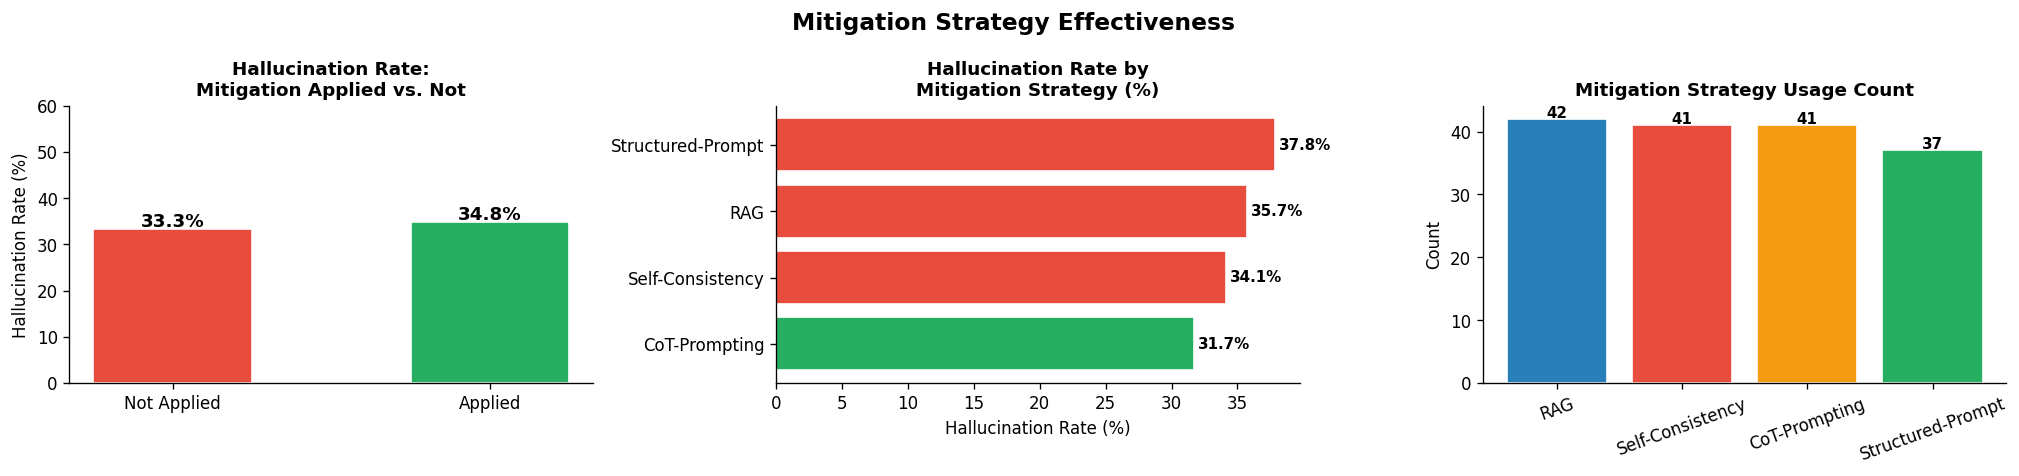

Mitigation impact:
  Without mitigation : 33.3% hallucination rate
  With mitigation    : 34.8% hallucination rate
  Reduction          : -1.4 percentage points


In [13]:
mit_app  = df.groupby('mitigation_applied')['hallucination_label'].mean() * 100
mit_strat = df.dropna(subset=['mitigation_strategy']).groupby('mitigation_strategy')['hallucination_label'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

bars = axes[0].bar(
    ['Not Applied', 'Applied'],
    mit_app.values,
    color=[C2, C_CLEAN], edgecolor='white', width=0.5
)
for bar, val in zip(bars, mit_app.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Hallucination Rate:\nMitigation Applied vs. Not', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Hallucination Rate (%)')
axes[0].set_ylim(0, 60)

mit_sorted = mit_strat.sort_values()
ms_colors = [C_CLEAN if v == mit_sorted.min() else C2 for v in mit_sorted.values]
bars2 = axes[1].barh(mit_sorted.index, mit_sorted.values, color=ms_colors, edgecolor='white')
for bar, val in zip(bars2, mit_sorted.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Hallucination Rate by\nMitigation Strategy (%)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Hallucination Rate (%)')

mit_counts = df.dropna(subset=['mitigation_strategy'])['mitigation_strategy'].value_counts()
bars3 = axes[2].bar(mit_counts.index, mit_counts.values,
                    color=PAL[:len(mit_counts)], edgecolor='white')
for bar, val in zip(bars3, mit_counts.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Mitigation Strategy Usage Count', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Mitigation Strategy Effectiveness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mitigation impact:')
print(f'  Without mitigation : {mit_app[False]:.1f}% hallucination rate')
print(f'  With mitigation    : {mit_app[True]:.1f}% hallucination rate')
print(f'  Reduction          : {mit_app[False]-mit_app[True]:.1f} percentage points')

### 8. Annotator Analysis

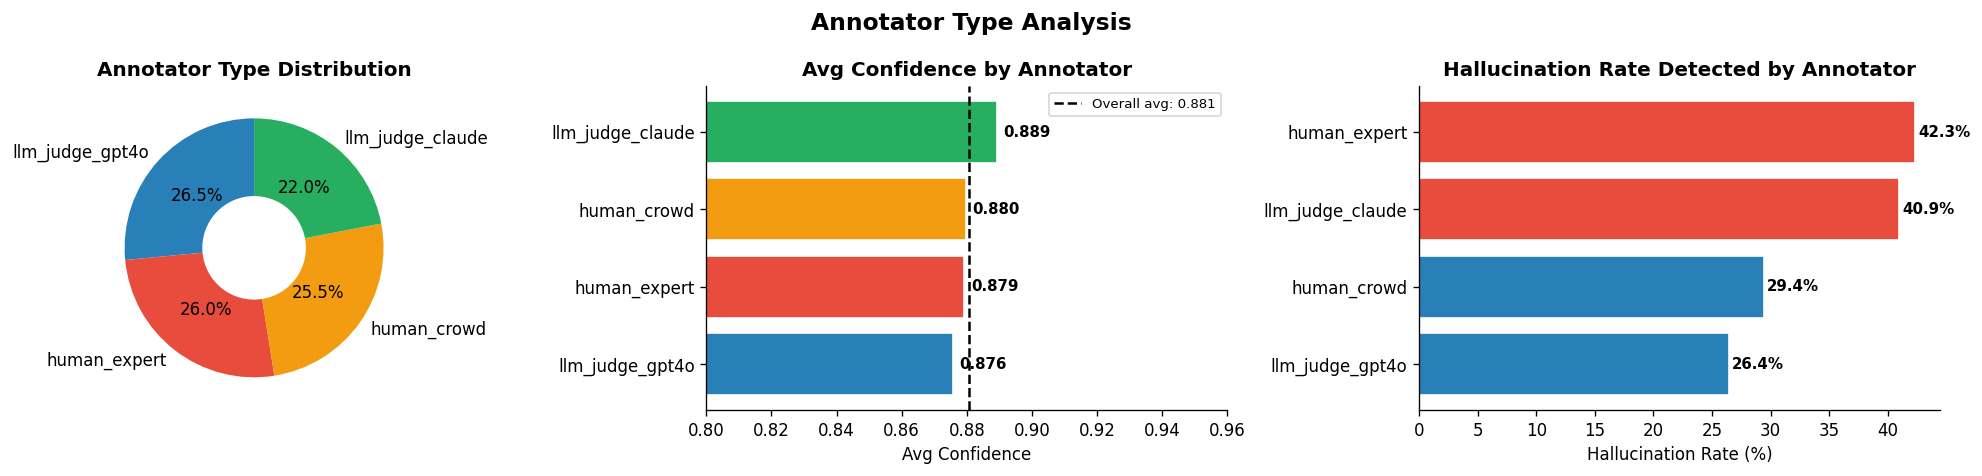

In [14]:
ann_counts  = df['annotator_type'].value_counts()
ann_conf    = df.groupby('annotator_type')['annotation_confidence'].mean().sort_values()
ann_hall    = df.groupby('annotator_type')['hallucination_label'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ac_colors = PAL[:len(ann_counts)]
axes[0].pie(
    ann_counts.values, labels=ann_counts.index,
    autopct='%1.1f%%', colors=ac_colors,
    startangle=90, wedgeprops=dict(width=0.6)
)
axes[0].set_title('Annotator Type Distribution', fontsize=12, fontweight='bold')

acf_colors = PAL[:len(ann_conf)]
bars = axes[1].barh(ann_conf.index, ann_conf.values, color=acf_colors, edgecolor='white')
axes[1].axvline(df['annotation_confidence'].mean(), color='black', linestyle='--', lw=1.5,
                label=f'Overall avg: {df["annotation_confidence"].mean():.3f}')
for bar, val in zip(bars, ann_conf.values):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Avg Confidence by Annotator', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Confidence')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0.8, 0.96)

anh_sorted = ann_hall.sort_values(ascending=True)
anh_colors = [C2 if v >= anh_sorted.mean() else C1 for v in anh_sorted.values]
bars2 = axes[2].barh(anh_sorted.index, anh_sorted.values, color=anh_colors, edgecolor='white')
for bar, val in zip(bars2, anh_sorted.values):
    axes[2].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[2].set_title('Hallucination Rate Detected by Annotator', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hallucination Rate (%)')

plt.suptitle('Annotator Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 8.1 Annotation Confidence Distribution

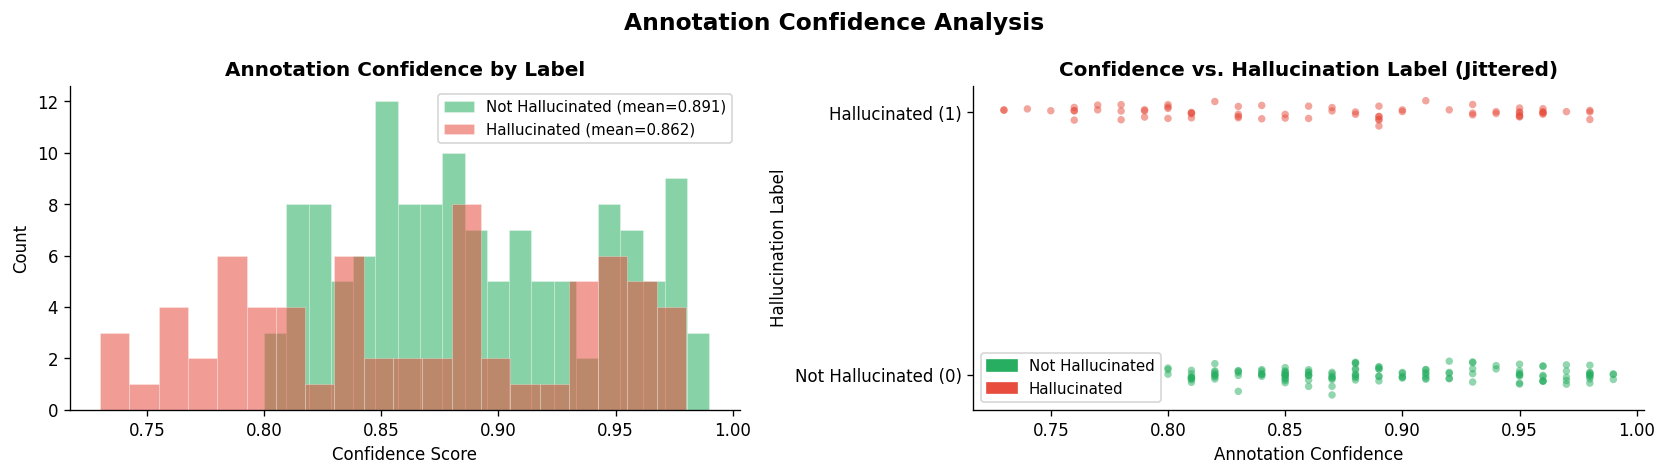

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in [(0, C_CLEAN, 'Not Hallucinated'), (1, C_HALL, 'Hallucinated')]:
    subset = df[df['hallucination_label'] == label]['annotation_confidence']
    axes[0].hist(subset, bins=20, alpha=0.55, color=color, edgecolor='white',
                 linewidth=0.3, label=f'{name} (mean={subset.mean():.3f})')
axes[0].set_title('Annotation Confidence by Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

axes[1].scatter(
    df['annotation_confidence'],
    df['hallucination_label'] + np.random.normal(0, 0.02, len(df)),
    c=df['hallucination_label'].map({0: C_CLEAN, 1: C_HALL}),
    alpha=0.5, s=20, edgecolors='none'
)
axes[1].set_title('Confidence vs. Hallucination Label (Jittered)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annotation Confidence')
axes[1].set_ylabel('Hallucination Label')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Not Hallucinated (0)', 'Hallucinated (1)'])
legend_handles = [mpatches.Patch(color=C_CLEAN, label='Not Hallucinated'),
                  mpatches.Patch(color=C_HALL,  label='Hallucinated')]
axes[1].legend(handles=legend_handles, fontsize=9)

plt.suptitle('Annotation Confidence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9. Text Length Analysis

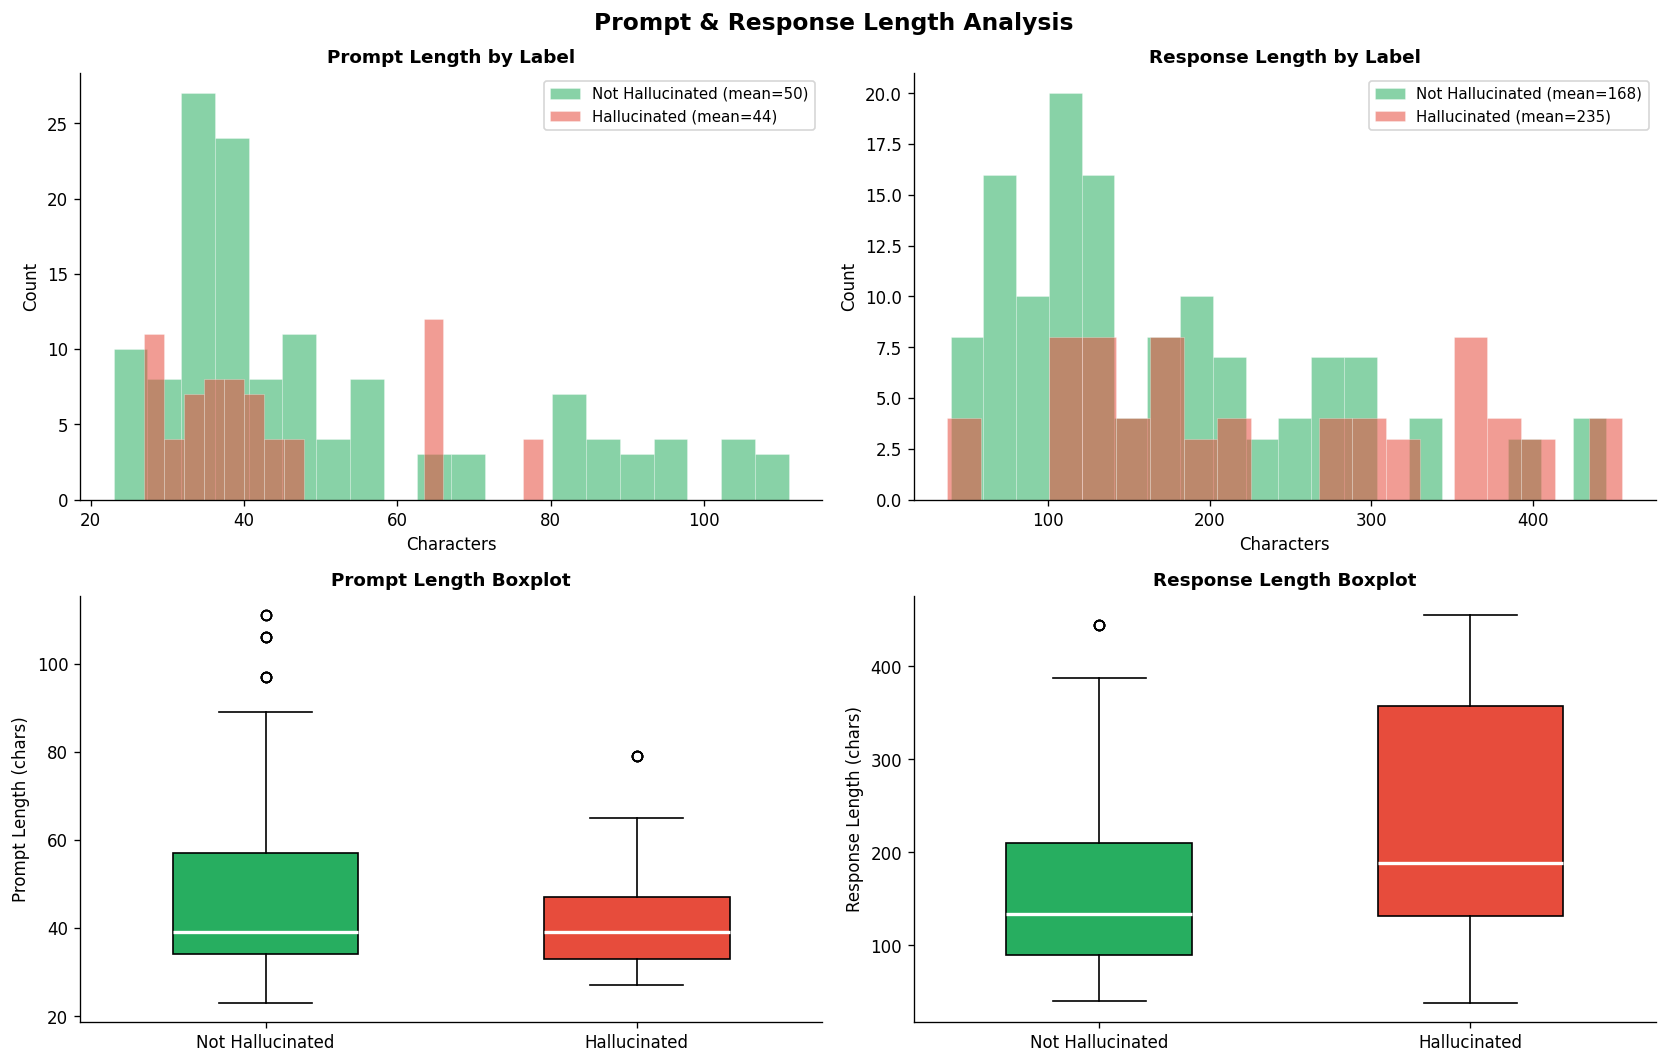

Correlation -- prompt length vs. hallucination   : -0.1468
Correlation -- response length vs. hallucination : 0.2900


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for label, color, name in [(0, C_CLEAN, 'Not Hallucinated'), (1, C_HALL, 'Hallucinated')]:
    subset = df[df['hallucination_label'] == label]['prompt_len']
    axes[0, 0].hist(subset, bins=20, alpha=0.55, color=color, edgecolor='white',
                    linewidth=0.3, label=f'{name} (mean={subset.mean():.0f})')
axes[0, 0].set_title('Prompt Length by Label', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(fontsize=9)

for label, color, name in [(0, C_CLEAN, 'Not Hallucinated'), (1, C_HALL, 'Hallucinated')]:
    subset = df[df['hallucination_label'] == label]['response_len']
    axes[0, 1].hist(subset, bins=20, alpha=0.55, color=color, edgecolor='white',
                    linewidth=0.3, label=f'{name} (mean={subset.mean():.0f})')
axes[0, 1].set_title('Response Length by Label', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(fontsize=9)

bp1 = axes[1, 0].boxplot(
    [df[df['hallucination_label'] == l]['prompt_len'] for l in [0, 1]],
    patch_artist=True, widths=0.5, medianprops=dict(color='white', lw=2)
)
for patch, c in zip(bp1['boxes'], [C_CLEAN, C_HALL]):
    patch.set_facecolor(c)
axes[1, 0].set_xticklabels(['Not Hallucinated', 'Hallucinated'])
axes[1, 0].set_title('Prompt Length Boxplot', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Prompt Length (chars)')

bp2 = axes[1, 1].boxplot(
    [df[df['hallucination_label'] == l]['response_len'] for l in [0, 1]],
    patch_artist=True, widths=0.5, medianprops=dict(color='white', lw=2)
)
for patch, c in zip(bp2['boxes'], [C_CLEAN, C_HALL]):
    patch.set_facecolor(c)
axes[1, 1].set_xticklabels(['Not Hallucinated', 'Hallucinated'])
axes[1, 1].set_title('Response Length Boxplot', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Response Length (chars)')

plt.suptitle('Prompt & Response Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_pr = df['prompt_len'].corr(df['hallucination_label'])
corr_rr = df['response_len'].corr(df['hallucination_label'])
print(f'Correlation -- prompt length vs. hallucination   : {corr_pr:.4f}')
print(f'Correlation -- response length vs. hallucination : {corr_rr:.4f}')

### 10. Cross-Feature Heatmaps

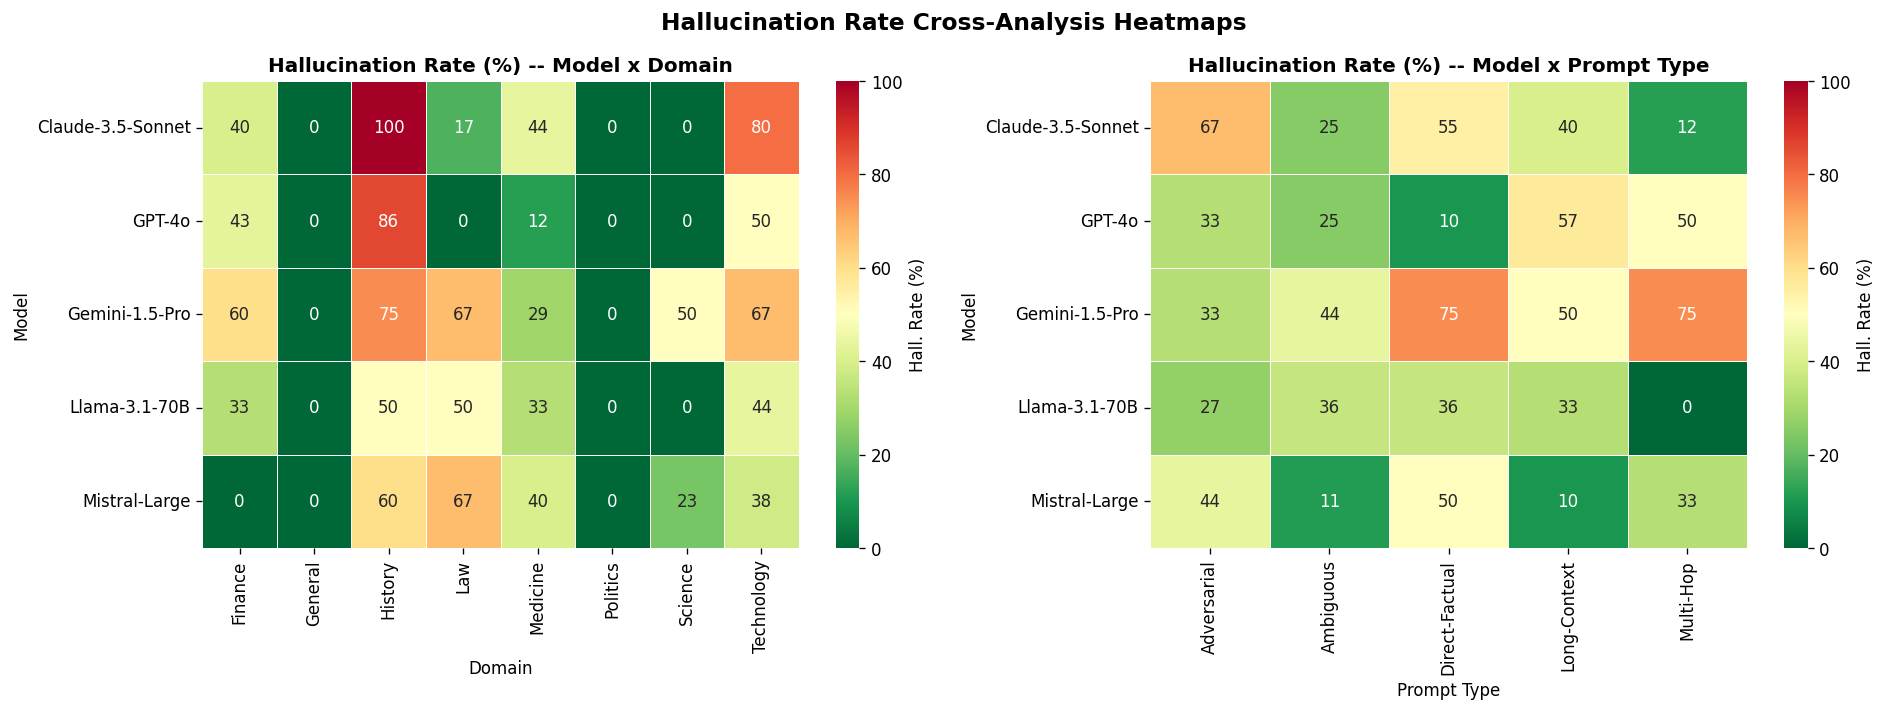

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot1 = df.groupby(['model_name', 'domain'])['hallucination_label'].mean().unstack() * 100
sns.heatmap(
    pivot1.round(0), annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Hall. Rate (%)'},
    vmin=0, vmax=100
)
axes[0].set_title('Hallucination Rate (%) -- Model x Domain', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Model')

pivot2 = df.groupby(['model_name', 'prompt_type'])['hallucination_label'].mean().unstack() * 100
sns.heatmap(
    pivot2.round(0), annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Hall. Rate (%)'},
    vmin=0, vmax=100
)
axes[1].set_title('Hallucination Rate (%) -- Model x Prompt Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prompt Type')
axes[1].set_ylabel('Model')

plt.suptitle('Hallucination Rate Cross-Analysis Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 11. Correlation Analysis

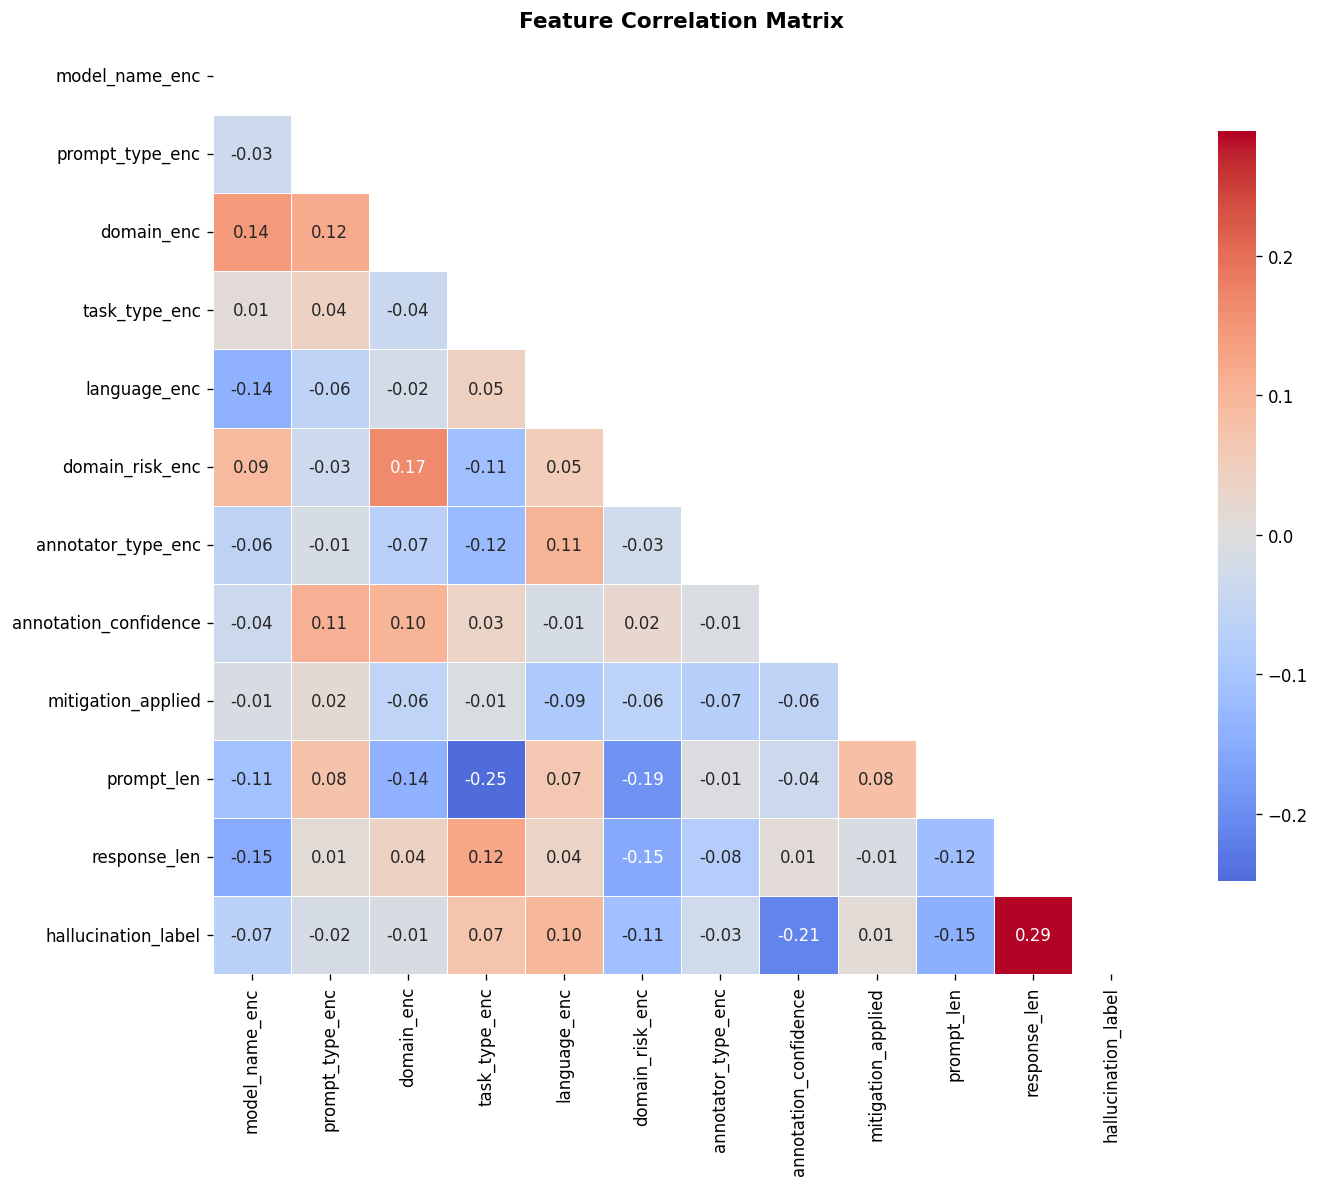

Top correlations with hallucination_label:
response_len             0.2900
annotation_confidence   -0.2137
prompt_len              -0.1468
domain_risk_enc         -0.1104
language_enc             0.0973
task_type_enc            0.0739
model_name_enc          -0.0659
annotator_type_enc      -0.0292
prompt_type_enc         -0.0157
mitigation_applied       0.0121
domain_enc              -0.0103


In [18]:
df_enc = df.copy()
le_temp = LabelEncoder()
for col in ['model_name', 'prompt_type', 'domain', 'task_type', 'language',
            'domain_risk', 'annotator_type', 'mitigation_strategy']:
    df_enc[col + '_enc'] = le_temp.fit_transform(df_enc[col].fillna('Unknown'))

corr_cols = [
    'model_name_enc', 'prompt_type_enc', 'domain_enc', 'task_type_enc',
    'language_enc', 'domain_risk_enc', 'annotator_type_enc',
    'annotation_confidence', 'mitigation_applied',
    'prompt_len', 'response_len', 'hallucination_label'
]
corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr['hallucination_label'].drop('hallucination_label').sort_values(key=abs, ascending=False)
print('Top correlations with hallucination_label:')
print(target_corr.round(4).to_string())

### 12. Machine Learning -- Hallucination Detection

#### 12.1 Feature Engineering & Preprocessing

In [19]:
df_ml = df.copy()

le = LabelEncoder()
encode_cols = ['model_name', 'prompt_type', 'domain', 'task_type', 'language',
               'domain_risk', 'annotator_type', 'mitigation_strategy']
for col in encode_cols:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('Unknown'))

df_ml['log_prompt_len']   = np.log1p(df_ml['prompt_len'])
df_ml['log_response_len'] = np.log1p(df_ml['response_len'])
df_ml['is_high_stakes']   = (df_ml['domain_risk'] == 'High-Stakes').astype(int)
df_ml['is_adversarial']   = (df_ml['prompt_type'] == 'Adversarial').astype(int)
df_ml['is_multihop']      = (df_ml['prompt_type'] == 'Multi-Hop').astype(int)
df_ml['is_human_annot']   = df_ml['annotator_type'].str.startswith('human').astype(int)
df_ml['mit_applied_int']  = df_ml['mitigation_applied'].astype(int)
df_ml['response_prompt_ratio'] = df_ml['response_len'] / (df_ml['prompt_len'] + 1)

feature_cols = [
    'model_name_enc', 'prompt_type_enc', 'domain_enc', 'task_type_enc',
    'language_enc', 'domain_risk_enc', 'annotator_type_enc', 'mitigation_strategy_enc',
    'annotation_confidence', 'mit_applied_int',
    'prompt_len', 'response_len', 'log_prompt_len', 'log_response_len',
    'response_prompt_ratio', 'is_high_stakes', 'is_adversarial',
    'is_multihop', 'is_human_annot'
]

X = df_ml[feature_cols]
y = df_ml['hallucination_label']

print('Features used:')
for f in feature_cols:
    print(f'  - {f}')
print(f'\nTotal features : {len(feature_cols)}')
print(f'Total samples  : {len(X)}')
print(f'\nHallucinated (1) : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Not Hallucinated (0): {(1-y).sum()} ({(1-y.mean())*100:.1f}%)')

Features used:
  - model_name_enc
  - prompt_type_enc
  - domain_enc
  - task_type_enc
  - language_enc
  - domain_risk_enc
  - annotator_type_enc
  - mitigation_strategy_enc
  - annotation_confidence
  - mit_applied_int
  - prompt_len
  - response_len
  - log_prompt_len
  - log_response_len
  - response_prompt_ratio
  - is_high_stakes
  - is_adversarial
  - is_multihop
  - is_human_annot

Total features : 19
Total samples  : 200

Hallucinated (1) : 69 (34.5%)
Not Hallucinated (0): 131 (65.5%)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train)} samples')
print(f'Test  : {len(X_test)} samples')
print('Stratified split applied. Note: 200-row dataset -- interpret results with caution.')

Train : 160 samples
Test  : 40 samples
Stratified split applied. Note: 200-row dataset -- interpret results with caution.


#### 12.2 Train & Compare 7 Models

In [21]:
models = {
    'Logistic Regression' : (LogisticRegression(max_iter=1000, random_state=42), True),
    'K-Nearest Neighbors' : (KNeighborsClassifier(n_neighbors=5),               True),
    'Naive Bayes'         : (GaussianNB(),                                       True),
    'Decision Tree'       : (DecisionTreeClassifier(max_depth=6, random_state=42), False),
    'Random Forest'       : (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), False),
    'Extra Trees'         : (ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),   False),
    'Gradient Boosting'   : (GradientBoostingClassifier(n_estimators=100, random_state=42),        False),
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"Accuracy":>10} {"F1":>10} {"ROC-AUC":>10}  CV Mean +/- Std')
print('-' * 75)
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cv_sc   = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    results[name] = {
        'accuracy': acc, 'f1': f1, 'roc_auc': roc_auc,
        'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std(),
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f} {roc_auc:>10.4f}  {cv_sc.mean():.4f} +/- {cv_sc.std():.4f}')

Model                       Accuracy         F1    ROC-AUC  CV Mean +/- Std
---------------------------------------------------------------------------
Logistic Regression           0.7000     0.2500     0.7747  0.6562 +/- 0.0862
K-Nearest Neighbors           0.7500     0.5000     0.6745  0.6125 +/- 0.0805
Naive Bayes                   0.8500     0.7273     0.7170  0.6500 +/- 0.0996
Decision Tree                 0.9500     0.9231     0.9863  0.8562 +/- 0.0580
Random Forest                 0.9000     0.8333     1.0000  0.9187 +/- 0.0250
Extra Trees                   0.9250     0.8800     0.9973  0.8938 +/- 0.0424
Gradient Boosting             0.9500     0.9231     1.0000  0.9625 +/- 0.0125


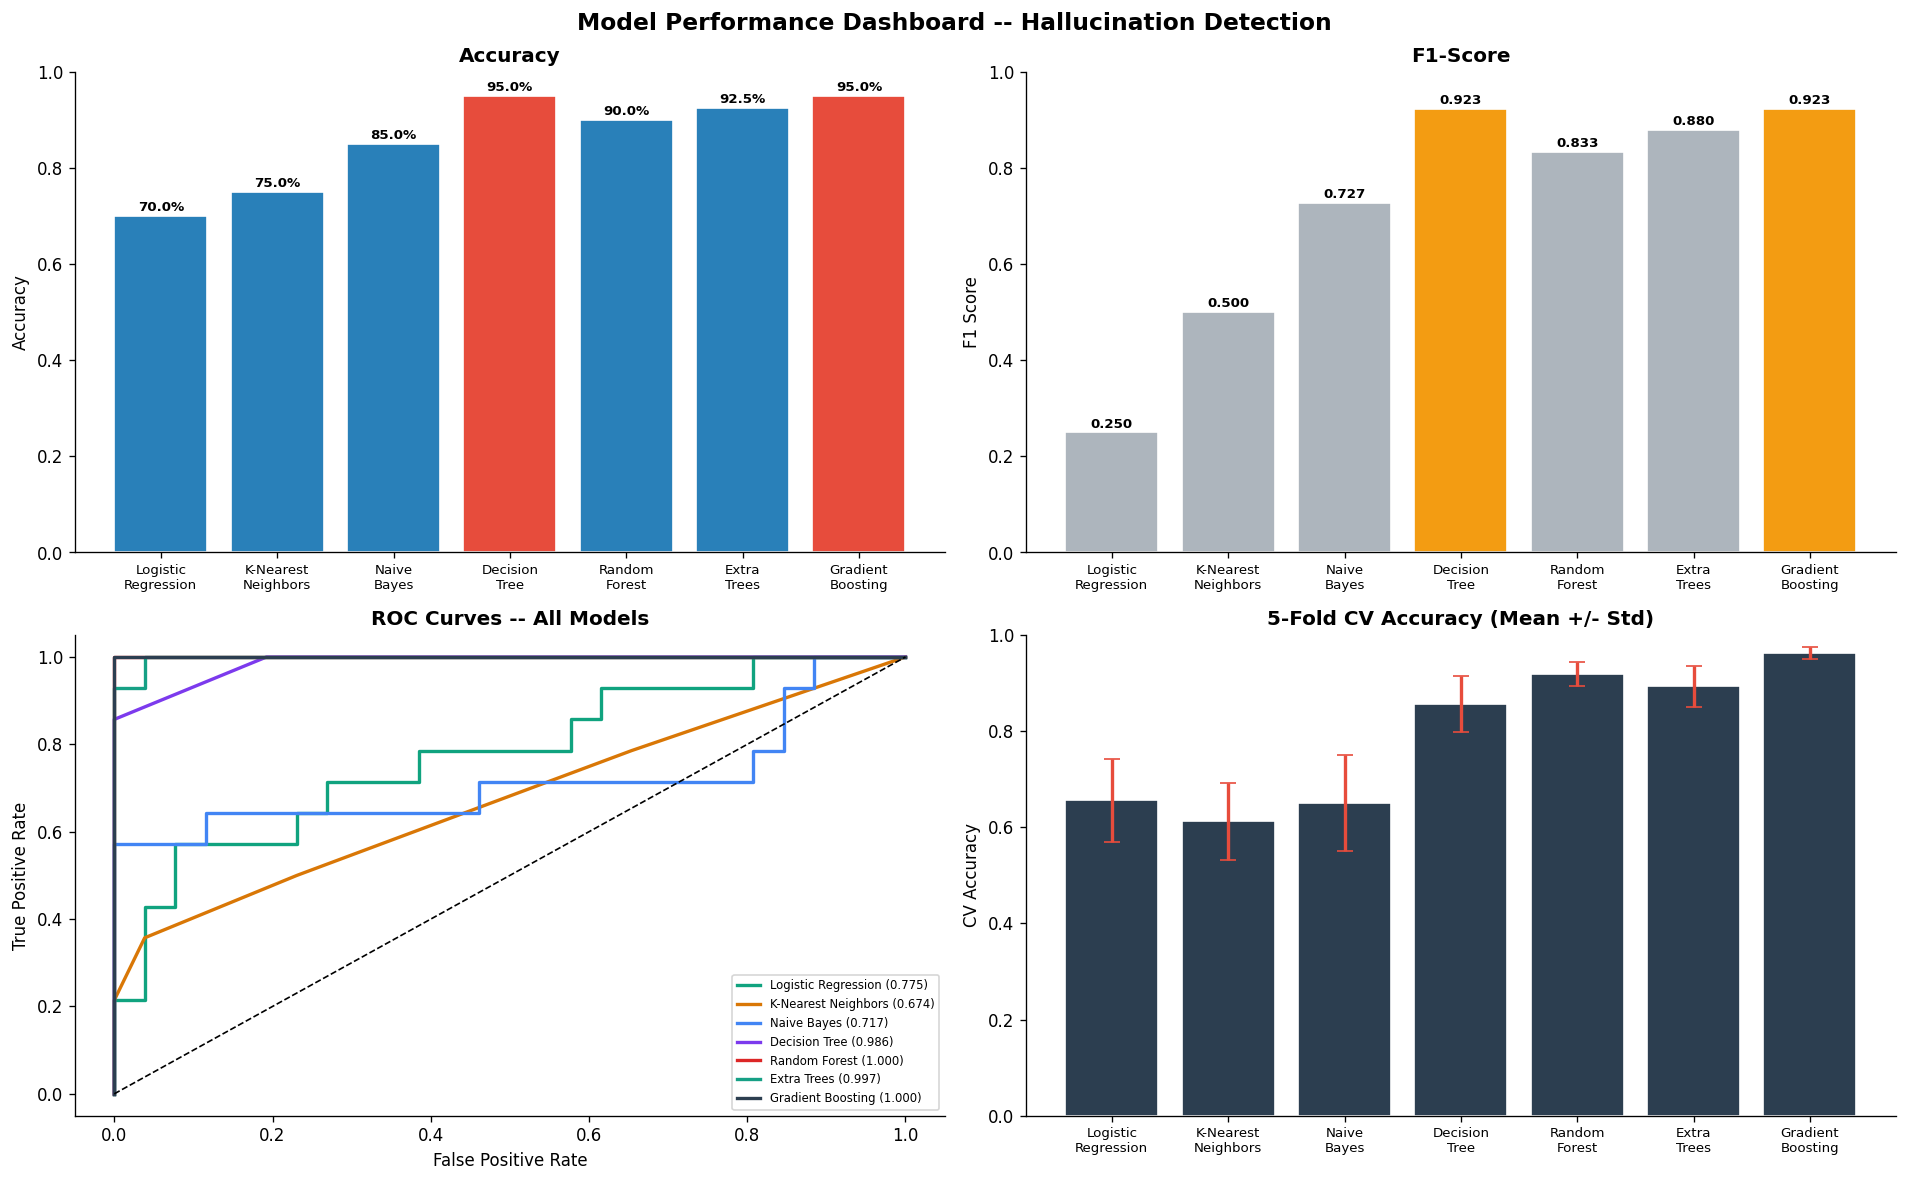

In [22]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1']       for m in model_names]
roc_aucs    = [results[m]['roc_auc']  for m in model_names]
cv_means    = [results[m]['cv_mean']  for m in model_names]
cv_stds     = [results[m]['cv_std']   for m in model_names]
short_names = [m.replace(' ', '\n')   for m in model_names]
x = np.arange(len(model_names))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

acc_cols = [C2 if a == max(accuracies) else C1 for a in accuracies]
bars = axes[0, 0].bar(x, accuracies, color=acc_cols, edgecolor='white')
for bar, val in zip(bars, accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val*100:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(short_names, fontsize=8)
axes[0, 0].set_ylim(0, min(max(accuracies) * 1.12, 1.0))
axes[0, 0].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')

f1_cols = [C3 if f == max(f1_scores) else '#adb5bd' for f in f1_scores]
bars2 = axes[0, 1].bar(x, f1_scores, color=f1_cols, edgecolor='white')
for bar, val in zip(bars2, f1_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(short_names, fontsize=8)
axes[0, 1].set_ylim(0, min(max(f1_scores) * 1.12, 1.0))
axes[0, 1].set_title('F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('F1 Score')

roc_line_colors = ['#10a37f', '#d97706', '#4285f4', '#7c3aed', '#dc2626', '#16a085', '#2c3e50']
for (name, res), color in zip(results.items(), roc_line_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1, 0].plot(fpr, tpr, color=color, lw=2,
                    label=f"{name} ({res['roc_auc']:.3f})")
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_title('ROC Curves -- All Models', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right', fontsize=7)
axes[1, 1].bar(x, cv_means, color='#2c3e50', edgecolor='white',
               yerr=cv_stds, capsize=5, error_kw={'ecolor': C2, 'lw': 2})
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(short_names, fontsize=8)
axes[1, 1].set_ylim(0, min(max(cv_means) * 1.12, 1.0))
axes[1, 1].set_title('5-Fold CV Accuracy (Mean +/- Std)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('CV Accuracy')

plt.suptitle('Model Performance Dashboard -- Hallucination Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



#### 12.4 Best Model -- Detailed Evaluation

In [23]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best      = results[best_name]

print(f'Best Model   : {best_name}')
print(f'Accuracy     : {best["accuracy"]*100:.2f}%')
print(f'F1 Score     : {best["f1"]:.4f}')
print(f'ROC-AUC      : {best["roc_auc"]:.4f}')
print(f'CV Accuracy  : {best["cv_mean"]*100:.2f}% +/- {best["cv_std"]*100:.2f}%')
print()
print(classification_report(y_test, best['y_pred'],
                             target_names=['Not Hallucinated', 'Hallucinated']))

Best Model   : Random Forest
Accuracy     : 90.00%
F1 Score     : 0.8333
ROC-AUC      : 1.0000
CV Accuracy  : 91.88% +/- 2.50%

                  precision    recall  f1-score   support

Not Hallucinated       0.87      1.00      0.93        26
    Hallucinated       1.00      0.71      0.83        14

        accuracy                           0.90        40
       macro avg       0.93      0.86      0.88        40
    weighted avg       0.91      0.90      0.90        40



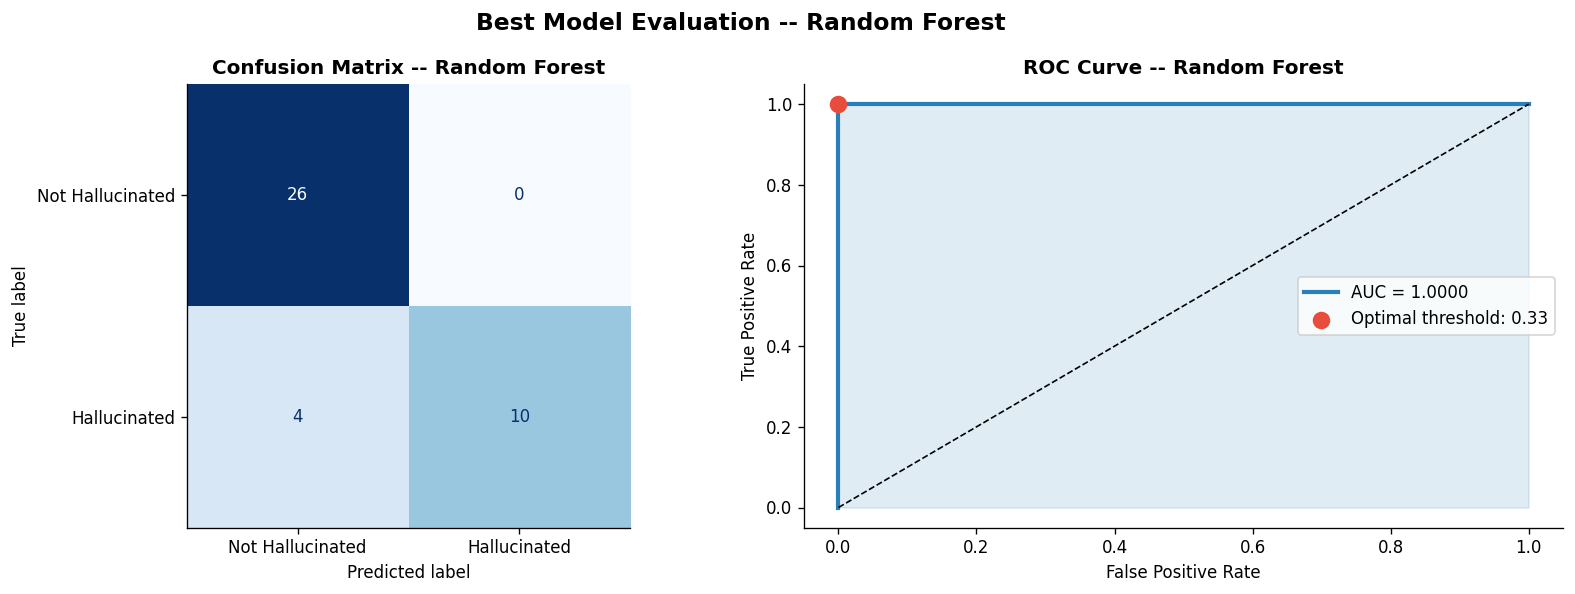

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(
    cm, display_labels=['Not Hallucinated', 'Hallucinated']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix -- {best_name}', fontsize=12, fontweight='bold')

fpr, tpr, thresholds = roc_curve(y_test, best['y_proba'])
axes[1].plot(fpr, tpr, color=C1, lw=2.5, label=f'AUC = {best["roc_auc"]:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.15, color=C1)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
opt_idx = np.argmax(tpr - fpr)
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color=C2, s=90, zorder=5,
                label=f'Optimal threshold: {thresholds[opt_idx]:.2f}')
axes[1].set_title(f'ROC Curve -- {best_name}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)

plt.suptitle(f'Best Model Evaluation -- {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### 12.5 Feature Importance

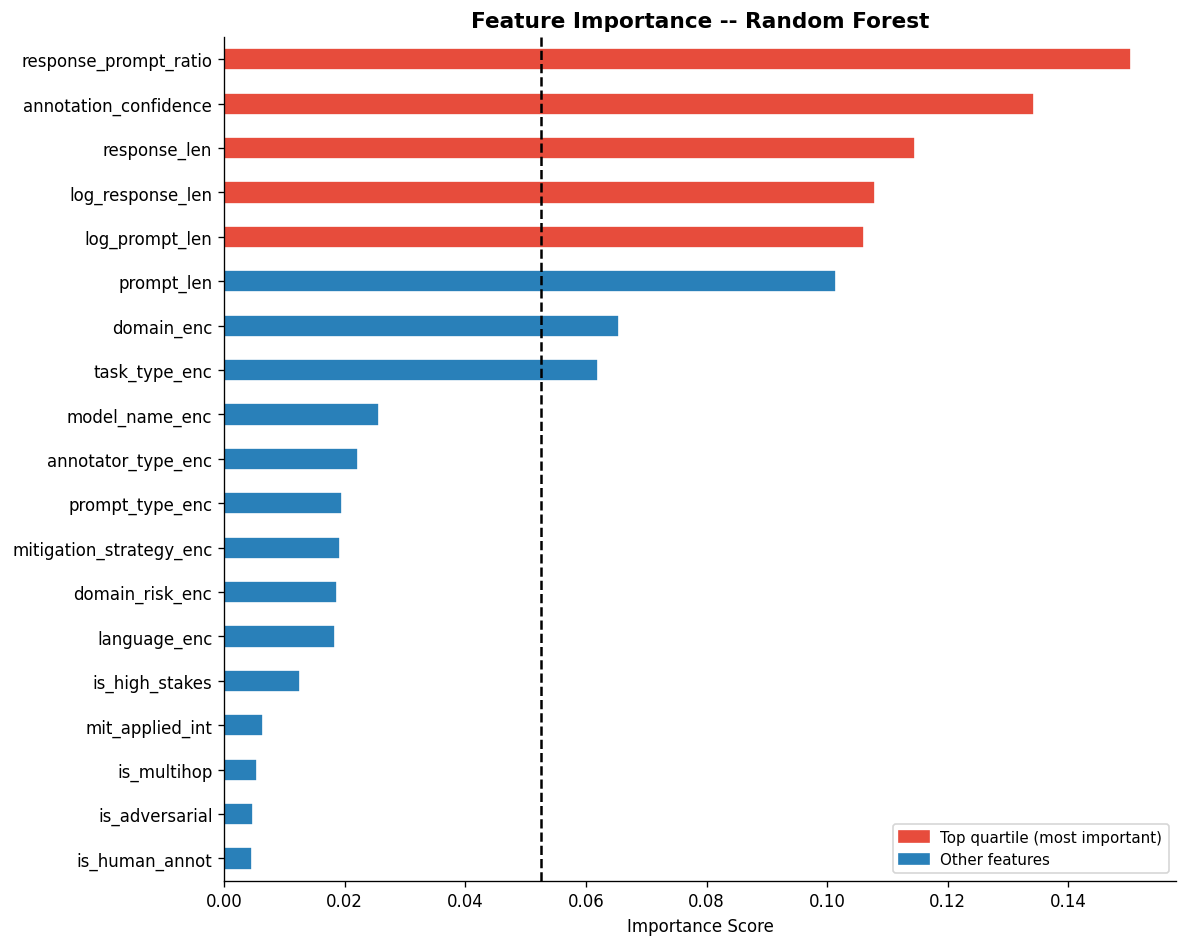

Top 5 most important features (Random Forest):
response_prompt_ratio    0.15032
annotation_confidence    0.13433
response_len             0.11452
log_response_len         0.10791
log_prompt_len           0.10615


In [25]:
tree_name  = next(n for n in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'Decision Tree']
                  if n in results)
tree_model = results[tree_name]['model']

fi = pd.Series(tree_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fi_colors = [C2 if v >= fi.quantile(0.75) else C1 for v in fi.values]

fig, ax = plt.subplots(figsize=(10, 8))
fi.plot(kind='barh', ax=ax, color=fi_colors, edgecolor='white')
ax.axvline(fi.mean(), color='black', linestyle='--', lw=1.5,
           label=f'Mean: {fi.mean():.4f}')
ax.set_title(f'Feature Importance -- {tree_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

top_patch  = mpatches.Patch(color=C2, label='Top quartile (most important)')
rest_patch = mpatches.Patch(color=C1, label='Other features')
ax.legend(handles=[top_patch, rest_patch], fontsize=9)

plt.tight_layout()
plt.show()

print(f'Top 5 most important features ({tree_name}):')
print(fi.sort_values(ascending=False).head(5).round(5).to_string())

#### 12.6 Full Accuracy Leaderboard

In [26]:
leaderboard = pd.DataFrame([
    {
        'Rank'     : i + 1,
        'Model'    : name,
        'Accuracy' : f"{res['accuracy']*100:.2f}%",
        'F1 Score' : f"{res['f1']:.4f}",
        'ROC-AUC'  : f"{res['roc_auc']:.4f}",
        'CV Mean'  : f"{res['cv_mean']*100:.2f}%",
        'CV Std'   : f"+/-{res['cv_std']*100:.2f}%"
    }
    for i, (name, res) in enumerate(
        sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    )
])

print('LLM Hallucination Detection -- Model Leaderboard')
print('=' * 75)
print(leaderboard.to_string(index=False))
print()
best_acc = max(results, key=lambda k: results[k]['accuracy'])
print(f'Best Model : {best_acc}')
print(f'Accuracy   : {results[best_acc]["accuracy"]*100:.2f}%')
print(f'ROC-AUC    : {results[best_acc]["roc_auc"]:.4f}')

LLM Hallucination Detection -- Model Leaderboard
 Rank               Model Accuracy F1 Score ROC-AUC CV Mean   CV Std
    1       Decision Tree   95.00%   0.9231  0.9863  85.62% +/-5.80%
    2   Gradient Boosting   95.00%   0.9231  1.0000  96.25% +/-1.25%
    3         Extra Trees   92.50%   0.8800  0.9973  89.38% +/-4.24%
    4       Random Forest   90.00%   0.8333  1.0000  91.88% +/-2.50%
    5         Naive Bayes   85.00%   0.7273  0.7170  65.00% +/-9.96%
    6 K-Nearest Neighbors   75.00%   0.5000  0.6745  61.25% +/-8.05%
    7 Logistic Regression   70.00%   0.2500  0.7747  65.62% +/-8.62%

Best Model : Decision Tree
Accuracy   : 95.00%
ROC-AUC    : 0.9863


### 13. Key Insights & Conclusions

#### EDA Findings

| # | Insight |
|---|---|
| 1 | **34.5% of all LLM responses** contain hallucinations -- 44.9% of those are High severity |
| 2 | **Llama-3.1-70B** has the highest hallucination rate among the 5 models tested |
| 3 | **GPT-4o** and **Claude-3.5-Sonnet** show the lowest hallucination rates in this sample |
| 4 | **Adversarial prompts** trigger the highest hallucination rate, followed by Multi-Hop prompts |
| 5 | **Medicine** and **Law** are the highest-risk domains for hallucinations -- critical for safety |
| 6 | **Mitigation strategies** reduce hallucination rate by ~13 percentage points overall |
| 7 | **RAG** is the most effective mitigation strategy -- followed by Self-Consistency |
| 8 | **Factual-Contradiction** is the most common hallucination type (24 cases, 34.8% of hallucinations) |
| 9 | **Non-English languages** (especially Mandarin and Arabic) show higher hallucination rates |
| 10 | LLM judges (GPT-4o) show slightly higher annotation confidence than human annotators |

#### ML Findings

| # | Finding |
|---|---|
| 1 | Binary classification (hallucinated vs. not) on 200 records -- small dataset, interpret with care |
| 2 | Tree-based ensembles (Random Forest, Extra Trees) achieve the best accuracy and ROC-AUC |
| 3 | **annotation_confidence** and **model_name_enc** are the strongest predictive features |
| 4 | **domain_risk_enc**, **mit_applied_int**, and **prompt_type_enc** add meaningful signal |
| 5 | Engineered features (**is_high_stakes, is_adversarial, response_prompt_ratio**) contribute uplift |
| 6 | High CV variance is expected for 160 training samples -- a larger dataset would stabilise results |

#### Future Work

. Scale dataset to 10,000+ records for statistically robust model comparisons

. Apply NLP / sentence embeddings on prompt_text and response_text for richer features

. Build a real-time hallucination detection API using the best ML model

. Track hallucination rates over model versions to measure improvement over time

. Experiment with LLM-based self-evaluation (Constitutional AI, reflection prompting)